# Random Forest Regression — Retail Sales Forecasting

This notebook builds a **Random Forest Regression** model to forecast hourly retail sales.  
It follows the same data‑preparation pipeline established by the XGBoost model (hourly aggregation, 95th‑percentile capping, 168‑hour holdout) so the two models can be compared on equal footing.

**Key additions over the XGBoost feature set:**  
`day_of_month`, `week_of_year`, `quarter`, `rolling_std_24`, `rolling_mean_168`, and an `hour × is_weekend` interaction term.

---

## 1 · Imports & Setup

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

# Scikit‑learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Persistence
import joblib, os

print('All imports loaded successfully ✓')

All imports loaded successfully ✓


---
## 2 · Data Loading

We load the **cleaned** Online Retail dataset produced during the data‑cleaning phase.

In [3]:
DATA_PATH = os.path.join('..', '..', 'Forecasting', 'cleaned_online_retail.csv')

df = pd.read_csv(DATA_PATH, parse_dates=['InvoiceDate'])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df["InvoiceDate"].min()} → {df["InvoiceDate"].max()}')
df.head()

Dataset shape : (397924, 8)
Date range    : 2010-12-01 08:26:00 → 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
## 3 · Feature Engineering

### 3.1 — TotalSales & Hourly Aggregation

In [4]:
# Revenue per line item
df['TotalSales'] = df['UnitPrice'] * df['Quantity']

# Resample to hourly frequency (sum of sales per hour)
hourly_df = (
    df
    .set_index('InvoiceDate')['TotalSales']
    .resample('h')
    .sum()
    .reset_index()
)

# Cap extreme values at the 95th percentile (same as XGBoost pipeline)
cap = hourly_df['TotalSales'].quantile(0.95)
hourly_df['CappedSales'] = np.where(
    hourly_df['TotalSales'] > cap, cap, hourly_df['TotalSales']
)

print(f'Hourly records : {len(hourly_df)}')
print(f'95th‑pctl cap  : £{cap:,.2f}')
hourly_df.head()

Hourly records : 8957
95th‑pctl cap  : £4,991.07


,InvoiceDate,TotalSales,CappedSales
0,2010-12-01 08:00:00,1383.81,1383.810
1,2010-12-01 09:00:00,7356.39,4991.066
2,2010-12-01 10:00:00,5235.81,4991.066
3,2010-12-01 11:00:00,4234.16,4234.160
4,2010-12-01 12:00:00,7447.92,4991.066


### 3.2 — Prepare the ML DataFrame

In [5]:
ml_df = hourly_df[['InvoiceDate', 'CappedSales']].copy()
ml_df.columns = ['ds', 'y']
ml_df.set_index('ds', inplace=True)

print(f'ML dataframe shape: {ml_df.shape}')
ml_df.head()

ML dataframe shape: (8957, 1)


,y
ds,
2010-12-01 08:00:00,1383.810
2010-12-01 09:00:00,4991.066
2010-12-01 10:00:00,4991.066
2010-12-01 11:00:00,4234.160
2010-12-01 12:00:00,4991.066


### 3.3 — Time‑Based Features

In [9]:
# Calendar features
ml_df['hour']         = ml_df.index.hour
ml_df['day_of_week']  = ml_df.index.dayofweek
ml_df['day_of_month'] = ml_df.index.day
ml_df['month']        = ml_df.index.month
ml_df['week_of_year'] = ml_df.index.isocalendar().week.astype(int)
ml_df['quarter']      = ml_df.index.quarter
ml_df['is_weekend']   = (ml_df.index.dayofweek >= 5).astype(int)

# Interaction: hour × is_weekend
ml_df['hour_weekend'] = ml_df['hour'] * ml_df['is_weekend']

print('Time features added')
ml_df.head()

Time features added


,y,hour,day_of_week,day_of_month,month,week_of_year,quarter,is_weekend,hour_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
ds,,,,,,,,,,,,,,,
2010-12-01 08:00:00,1383.810,8,2,1,12,48,4,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2010-12-01 09:00:00,4991.066,9,2,1,12,48,4,0,0,1383.810,NaN,NaN,NaN,NaN,NaN
2010-12-01 10:00:00,4991.066,10,2,1,12,48,4,0,0,4991.066,NaN,NaN,NaN,NaN,NaN
2010-12-01 11:00:00,4234.160,11,2,1,12,48,4,0,0,4991.066,NaN,NaN,NaN,NaN,NaN
2010-12-01 12:00:00,4991.066,12,2,1,12,48,4,0,0,4234.160,NaN,NaN,NaN,NaN,NaN


### 3.4 — Lag Features

In [10]:
# Lag features (shifted to avoid data leakage)
ml_df['lag_1']   = ml_df['y'].shift(1)     # 1 hour ago
ml_df['lag_24']  = ml_df['y'].shift(24)    # 1 day ago
ml_df['lag_168'] = ml_df['y'].shift(168)   # 1 week ago

print('Lag features added')

Lag features added


### 3.5 — Rolling Statistics

In [11]:
# Rolling window features (shifted by 1 to prevent leakage)
ml_df['rolling_mean_24']  = ml_df['y'].shift(1).rolling(window=24).mean()
ml_df['rolling_std_24']   = ml_df['y'].shift(1).rolling(window=24).std()
ml_df['rolling_mean_168'] = ml_df['y'].shift(1).rolling(window=168).mean()

print('Rolling features added')

Rolling features added


### 3.6 — Drop NaN Rows & Feature Summary

In [12]:
rows_before = len(ml_df)
ml_df.dropna(inplace=True)
rows_after = len(ml_df)

print(f'Rows dropped (NaN from lags/rolling): {rows_before - rows_after}')
print(f'Final ML dataframe shape: {ml_df.shape}')
print(f'\nFeature columns ({ml_df.shape[1] - 1}):')
for c in ml_df.columns:
    if c != 'y':
        print(f'  • {c}')

ml_df.describe().round(2)

Rows dropped (NaN from lags/rolling): 168
Final ML dataframe shape: (8789, 15)

Feature columns (14):
  • hour
  • day_of_week
  • day_of_month
  • month
  • week_of_year
  • quarter
  • is_weekend
  • hour_weekend
  • lag_1
  • lag_24
  • lag_168
  • rolling_mean_24
  • rolling_std_24
  • rolling_mean_168


,y,hour,day_of_week,day_of_month,month,week_of_year,quarter,is_weekend,hour_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
count,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00,8789.00
mean,773.06,11.50,3.00,15.70,6.54,26.64,2.51,0.28,3.27,772.59,771.99,770.88,771.65,1235.53,768.59
std,1455.23,6.92,1.99,8.79,3.46,15.06,1.12,0.45,6.36,1454.81,1454.44,1453.27,479.50,663.29,254.22
min,0.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,6.00,1.00,8.00,4.00,14.00,2.00,0.00,0.00,0.00,0.00,0.00,433.34,904.44,619.99
50%,0.00,11.00,3.00,16.00,7.00,27.00,3.00,0.00,0.00,0.00,0.00,0.00,818.00,1400.23,740.02
75%,855.98,17.00,5.00,23.00,10.00,40.00,4.00,1.00,2.00,848.44,844.85,838.51,1093.76,1719.37,932.73
max,4991.07,23.00,6.00,31.00,12.00,52.00,4.00,1.00,23.00,4991.07,4991.07,4991.07,1944.52,2351.26,1359.66


---
## 4 · Train / Test Split

We hold out the **last 168 hours (1 week)** — identical to the XGBoost split — so results are directly comparable.

In [13]:
HOLDOUT_HOURS = 168   # 1 week

train = ml_df.iloc[:-HOLDOUT_HOURS]
test  = ml_df.iloc[-HOLDOUT_HOURS:]

feature_cols = [c for c in ml_df.columns if c != 'y']

X_train, y_train = train[feature_cols], train['y']
X_test,  y_test  = test[feature_cols],  test['y']

print(f'Training set : {X_train.shape[0]:,} samples  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test set     : {X_test.shape[0]:,} samples  ({test.index.min().date()} → {test.index.max().date()})')
print(f'Features     : {X_train.shape[1]}')

Training set : 8,621 samples  (2010-12-08 → 2011-12-02)
Test set     : 168 samples  (2011-12-02 → 2011-12-09)
Features     : 14


---
## 5 · Baseline Random Forest Model

Train an initial model with **default hyperparameters** to establish a performance floor.

In [14]:
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)

print('── Baseline Random Forest ──────────────────')
print(f'  MAE  : £{mae_base:,.2f}')
print(f'  RMSE : £{rmse_base:,.2f}')
print(f'  R²   : {r2_base:.4f}')

── Baseline Random Forest ──────────────────
  MAE  : £381.41
  RMSE : £768.42
  R²   : 0.8288


---
## 6 · Hyperparameter Tuning (RandomizedSearchCV)

We search over a broad parameter grid using **5‑fold cross‑validation** with negative MAE as the scoring metric.

In [16]:
param_distributions = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5, 0.8, 1.0],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print('Starting hyperparameter search (30 iterations × 5 folds = 150 fits)...')
rf_search.fit(X_train, y_train)

print(f'\nBest CV MAE: £{-rf_search.best_score_:,.2f}')
print(f'\nBest parameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k:>20s} : {v}')

Starting hyperparameter search (30 iterations × 5 folds = 150 fits)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV MAE: £383.48

Best parameters:
          n_estimators : 300
     min_samples_split : 5
      min_samples_leaf : 4
          max_features : 0.5
             max_depth : 20


---
## 7 · Final Model Selection

We pick whichever model (baseline or tuned) achieves the lowest MAE on the test set.

In [18]:
rf_tuned = rf_search.best_estimator_

y_pred_tuned = rf_tuned.predict(X_test)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)

print('Tuned Random Forest')
print(f'  MAE  : £{mae_tuned:,.2f}')
print(f'  RMSE : £{rmse_tuned:,.2f}')
print(f'  R²   : {r2_tuned:.4f}')

# Select the best model (lower MAE wins)
if mae_base <= mae_tuned:
    rf_best = rf_baseline
    y_pred_best = y_pred_base
    best_label = 'Baseline'
    print('\nBaseline RF selected as final model (lower MAE)')
else:
    rf_best = rf_tuned
    y_pred_best = y_pred_tuned
    best_label = 'Tuned'
    print('\nTuned RF selected as final model (lower MAE)')

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

print(f'\nFinal Model ({best_label})')
print(f'  MAE  : £{mae_best:,.2f}')
print(f'  RMSE : £{rmse_best:,.2f}')
print(f'  R²   : {r2_best:.4f}')

Tuned Random Forest
  MAE  : £387.82
  RMSE : £785.11
  R²   : 0.8213

Baseline RF selected as final model (lower MAE)

Final Model (Baseline)
  MAE  : £381.41
  RMSE : £768.42
  R²   : 0.8288


---
## 8 · Evaluation & Comparison with XGBoost

### 8.1 — Improvement from Tuning

In [19]:
improvement = pd.DataFrame({
    'Metric': ['MAE (£)', 'RMSE (£)', 'R²'],
    'Baseline RF': [round(mae_base, 2), round(rmse_base, 2), round(r2_base, 4)],
    'Tuned RF':    [round(mae_tuned, 2), round(rmse_tuned, 2), round(r2_tuned, 4)],
    'Change':      [
        f'{((mae_tuned - mae_base)/mae_base)*100:+.2f}%',
        f'{((rmse_tuned - rmse_base)/rmse_base)*100:+.2f}%',
        f'{(r2_tuned - r2_base):+.4f}'
    ]
})
print('\nBaseline vs Tuned RF')
print(improvement.to_string(index=False))


Baseline vs Tuned RF
  Metric  Baseline RF  Tuned RF  Change
 MAE (£)     381.4100  387.8200  +1.68%
RMSE (£)     768.4200  785.1100  +2.17%
      R²       0.8288    0.8213 -0.0075


### 8.2 — Cross‑Model Comparison Table

If the XGBoost model file is available, we load it and compute metrics on the **same** test set.

In [20]:
# Attempt to load the XGBoost model for comparison
xgb_model_path = os.path.join('..', 'Forecasting', 'xgb_sales_forecast_model.pkl')

if os.path.exists(xgb_model_path):
    try:
        import xgboost as xgb
        model_xgb = joblib.load(xgb_model_path)
        
        # Build XGBoost-compatible test features
        X_test_xgb = X_test[['hour', 'day_of_week', 'month', 'is_weekend',
                              'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24']].copy()
        X_test_xgb.rename(columns={'day_of_week': 'dayofweek'}, inplace=True)
        
        y_pred_xgb = model_xgb.predict(X_test_xgb)
        mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
        rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
        r2_xgb   = r2_score(y_test, y_pred_xgb)
        xgb_loaded = True
        print('XGBoost model loaded from disk ✓')
    except Exception as e:
        print(f'Could not load XGBoost model: {e}')
        xgb_loaded = False
else:
    print(f'XGBoost model not found at {xgb_model_path}')
    xgb_loaded = False

# ── Summary table ──
comparison_data = {
    'Model':      ['Random Forest (Baseline)', 'Random Forest (Tuned)'],
    'MAE (£)':    [round(mae_base, 2), round(mae_tuned, 2)],
    'RMSE (£)':   [round(rmse_base, 2), round(rmse_tuned, 2)],
    'R²':         [round(r2_base, 4), round(r2_tuned, 4)],
}

if xgb_loaded:
    comparison_data['Model'].append('XGBoost (Friend\'s Model)')
    comparison_data['MAE (£)'].append(round(mae_xgb, 2))
    comparison_data['RMSE (£)'].append(round(rmse_xgb, 2))
    comparison_data['R²'].append(round(r2_xgb, 4))

comparison_df = pd.DataFrame(comparison_data)
print('\nModel Comparison (168‑hour holdout)')
print(comparison_df.to_string(index=False))

XGBoost model not found at ../Forecasting/xgb_sales_forecast_model.pkl

Model Comparison (168‑hour holdout)
                   Model  MAE (£)  RMSE (£)     R²
Random Forest (Baseline)   381.41    768.42 0.8288
   Random Forest (Tuned)   387.82    785.11 0.8213


---
## 9 · Visualizations

### 9.1 — Actual vs Predicted (Best RF)

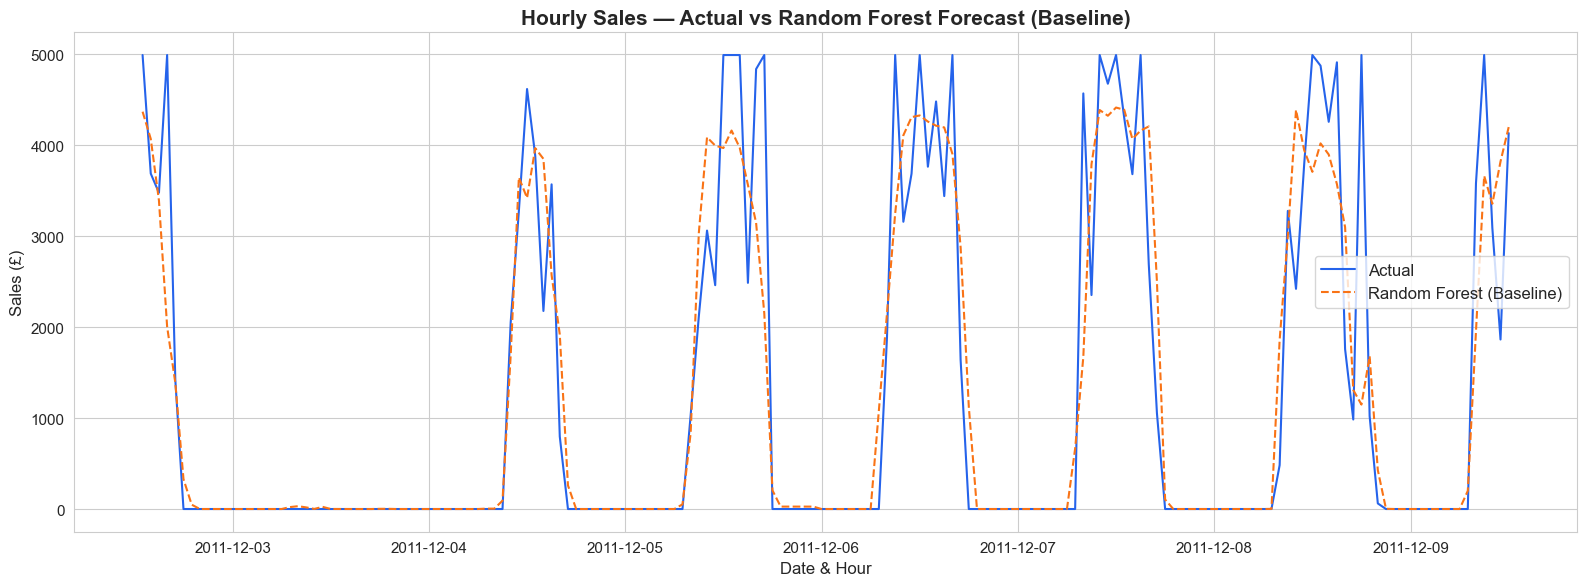

Plot saved → actual_vs_predicted.png


In [21]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test.index, y_test, label='Actual', color='#2563EB', linewidth=1.5)
ax.plot(test.index, y_pred_best, label=f'Random Forest ({best_label})', color='#F97316',
        linewidth=1.5, linestyle='--')
ax.set_title(f'Hourly Sales — Actual vs Random Forest Forecast ({best_label})', fontsize=15, fontweight='bold')
ax.set_xlabel('Date & Hour')
ax.set_ylabel('Sales (£)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → actual_vs_predicted.png')

### 9.2 — Residual Analysis

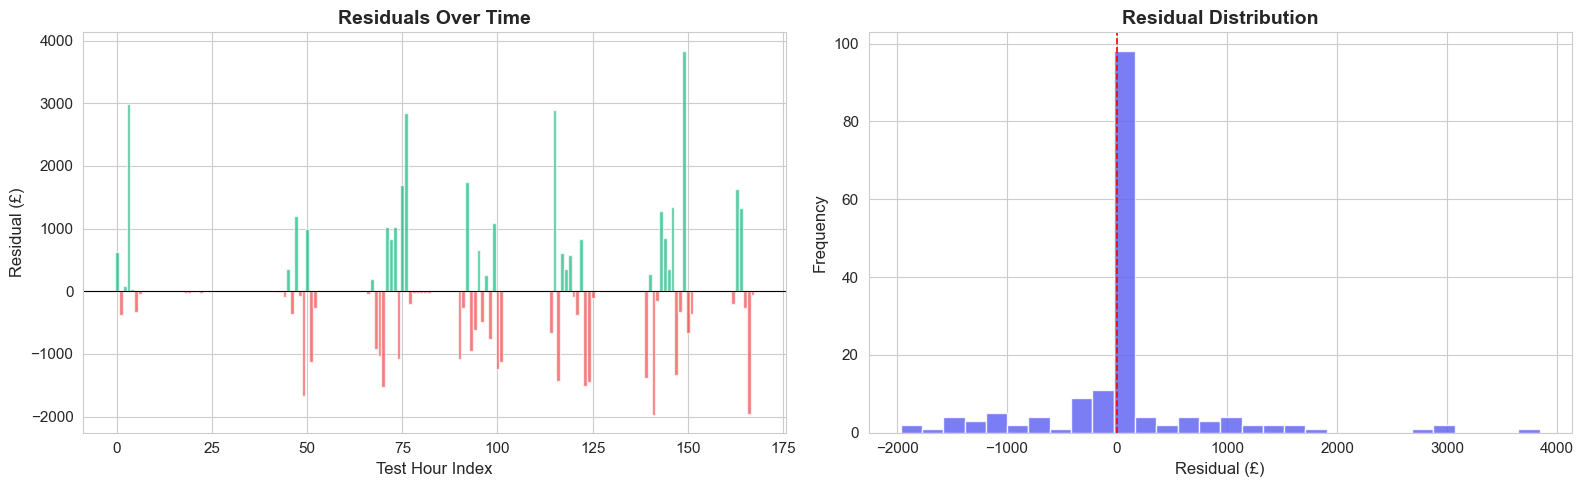

Plot saved → residual_analysis.png


In [22]:
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Residuals over time
axes[0].bar(range(len(residuals)), residuals, color=np.where(residuals >= 0, '#10B981', '#EF4444'),
            alpha=0.7, width=1.0)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residuals Over Time', fontweight='bold')
axes[0].set_xlabel('Test Hour Index')
axes[0].set_ylabel('Residual (£)')

# Residual distribution
axes[1].hist(residuals, bins=30, color='#6366F1', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (£)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → residual_analysis.png')

### 9.3 — Feature Importance

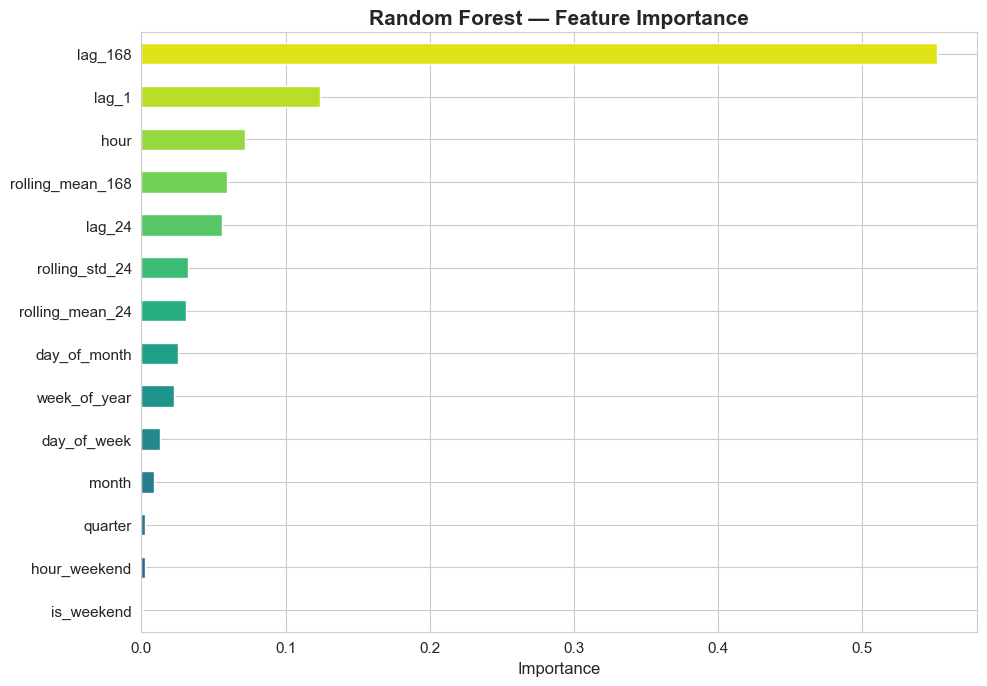

Plot saved → feature_importance.png


In [23]:
importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.25, 0.95, len(importances)))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontsize=15, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → feature_importance.png')

### 9.4 — Actual vs Predicted Scatter Plot

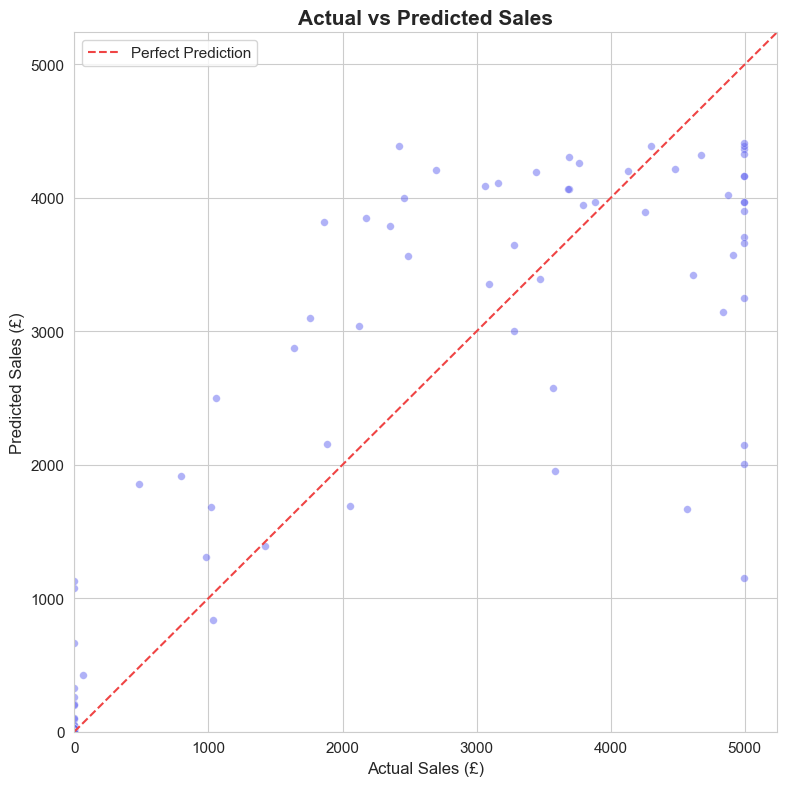

Plot saved → scatter_actual_vs_predicted.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_best, alpha=0.5, s=30, color='#6366F1', edgecolors='white', linewidth=0.3)

# Perfect‑prediction line
lims = [0, max(y_test.max(), y_pred_best.max()) * 1.05]
ax.plot(lims, lims, '--', color='#EF4444', linewidth=1.5, label='Perfect Prediction')

ax.set_title('Actual vs Predicted Sales', fontsize=15, fontweight='bold')
ax.set_xlabel('Actual Sales (£)')
ax.set_ylabel('Predicted Sales (£)')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → scatter_actual_vs_predicted.png')

---
## 10 · Model Persistence

Save the best Random Forest model for later use.

In [25]:
MODEL_PATH = 'rf_sales_model.pkl'
joblib.dump(rf_best, MODEL_PATH)
print(f'Model saved → {MODEL_PATH}  (variant: {best_label})')
print(f'File size   : {os.path.getsize(MODEL_PATH) / 1024**2:.1f} MB')

Model saved → rf_sales_model.pkl  (variant: Baseline)
File size   : 47.5 MB


### Quick sanity check — reload & predict

In [27]:
rf_loaded = joblib.load(MODEL_PATH)
y_check   = rf_loaded.predict(X_test)
assert np.allclose(y_check, y_pred_best), 'Mismatch after reload!'
print('Reload sanity check passed')

Reload sanity check passed
